# Metrics notebook 

In [1]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

In [2]:
# Notebook display options, change as your preference/syste

import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 
from pyMOE.generate import *  
from pyMOE.propagate import * 
from pyMOE.metrics import * 
from pyMOE.optimizer import * 
from pyMOE.ensemble import * 

In [3]:
# These metrics could be used to build specific loss functions 

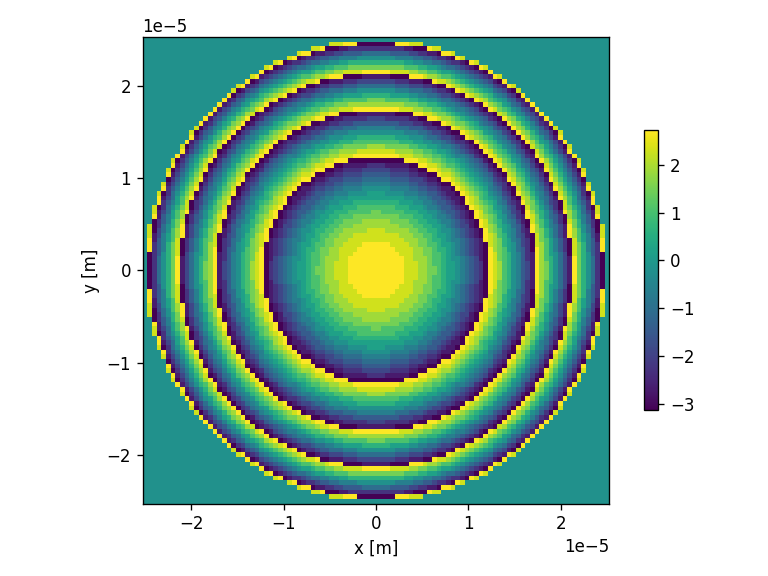

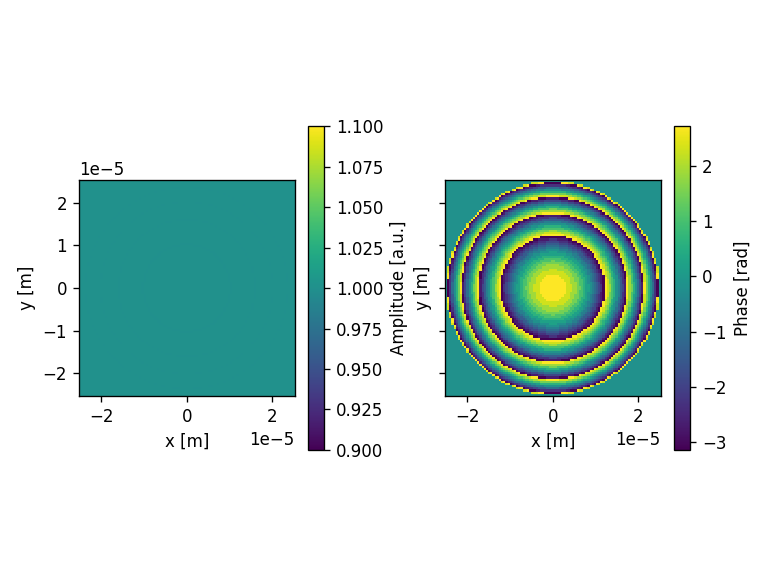

In [4]:
#number of pixels 
x_pixel = 100
y_pixel = 100


#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 150e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
#moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
#moe.plotting.plot_aperture(mask2)

# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )

moe.plotting.plot_aperture(mask2)
moe.plotting.plot_field(field)

## Point Spread Function (PSF)

Progress: [####################] 100.0%
Elapsed: 0:00:00.458489


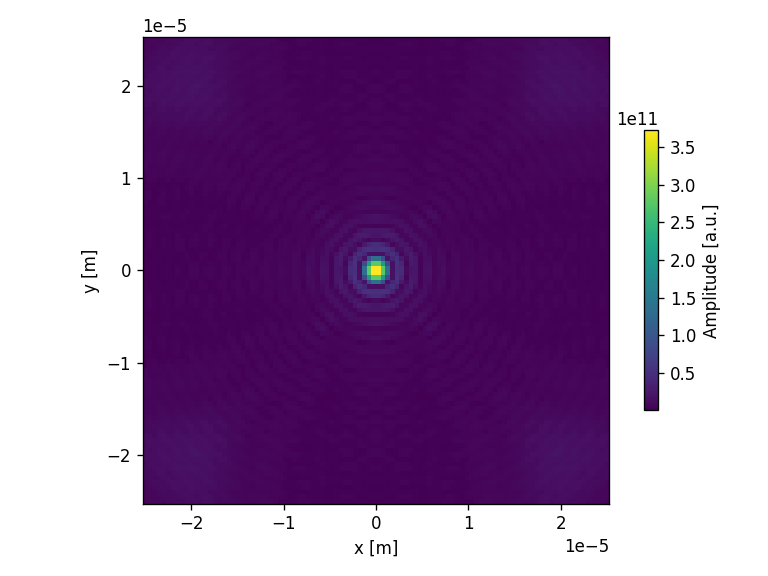

In [5]:
###Propagate field *10and calculate in plane YZ, using npix bins in Y
zmin = wavelength*10
zmax = 1.2* focal_length
nzs = 100

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2


x_pixel, y_pixel = 100,100

x = np.linspace(xmin, xmax, x_pixel )
y = np.linspace(ymin, ymax, y_pixel )
z = np.linspace(zmin, zmax, nzs)


screen = moe.field.Screen(x,y,z)
sfreq = moe.metrics.spatial_freq_space(screen)
# Propagate the field 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)

Exy = moe.field.Screen(x,y,z)
Exy.screen = np.reshape(EXYZ.screen[:,:, int(focal_length/zmax*nzs)], (x_pixel,y_pixel,1))

moe.plotting.plot_screen_XY(Exy, which='amplitude')

## Optical Transfer Function (OTF)

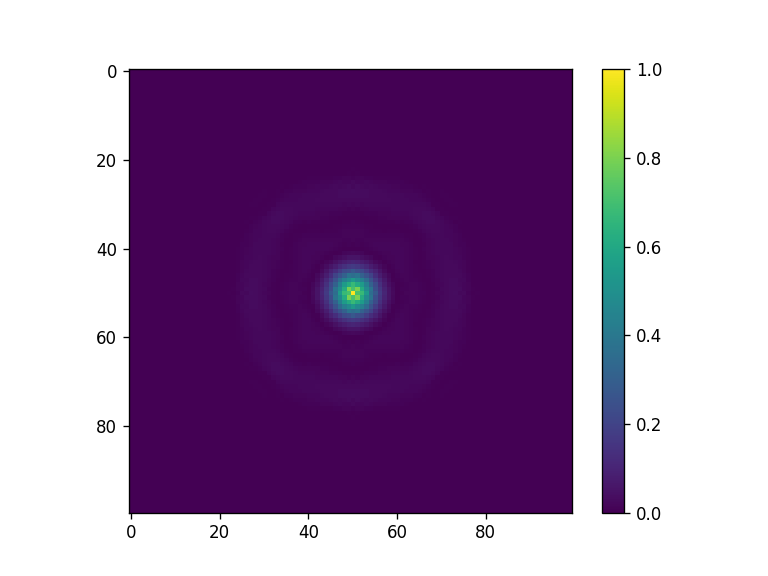

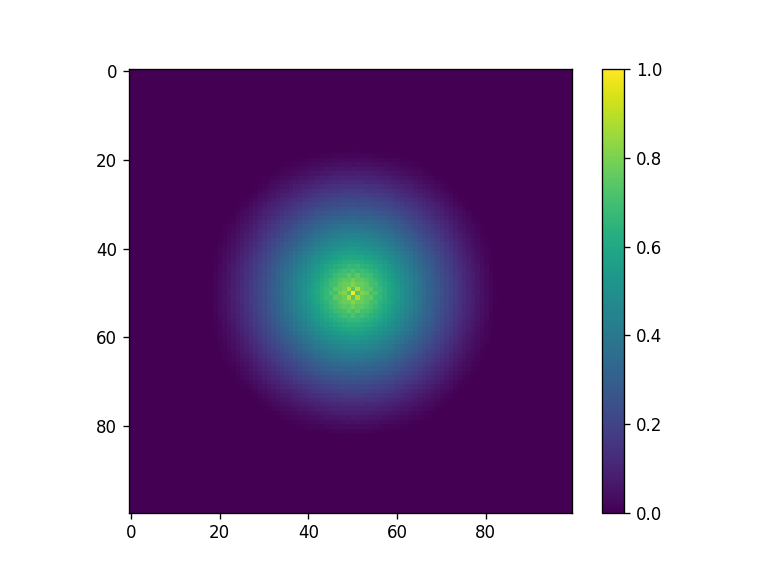

C:\Users\jcunha377\Desktop\pyMOE-main-v2.0\notebooks\8 - Metrics\../..\pyMOE\metrics.py:161: RuntimeWarning: invalid value encountered in arccos
  OTF = (2 / np.pi) * (np.arccos(rho / fc) - (rho / fc) * np.sqrt(1 - (rho / fc)**2))
C:\Users\jcunha377\Desktop\pyMOE-main-v2.0\notebooks\8 - Metrics\../..\pyMOE\metrics.py:161: RuntimeWarning: invalid value encountered in sqrt
  OTF = (2 / np.pi) * (np.arccos(rho / fc) - (rho / fc) * np.sqrt(1 - (rho / fc)**2))


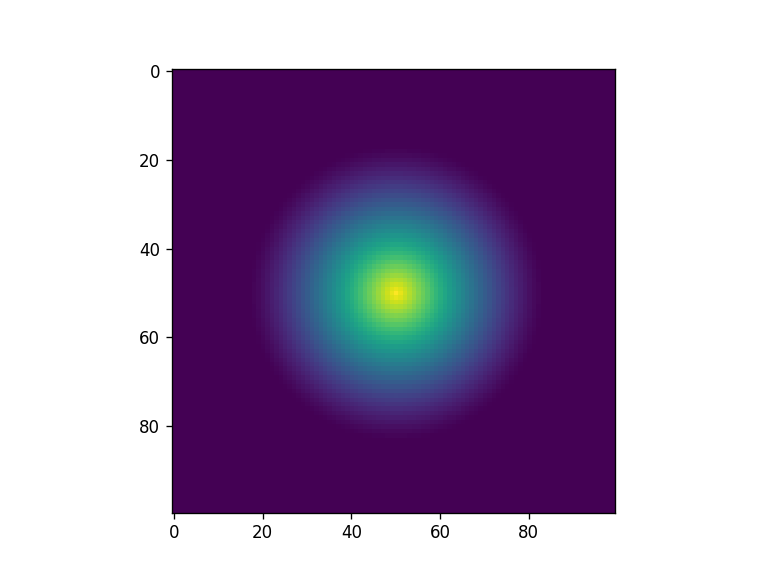

In [6]:
#Calculate the OTF out of focus and in focus 
import scipy.fftpack as sfft

o1 = moe.metrics.calculate_OTF(np.abs(screen.screen[:,:,-1])**2 , plot_OTF=True);
o2 = moe.metrics.calculate_OTF(np.abs(Exy.screen[:,:,-1])**2  , plot_OTF=True);

D = np.max(Exy.x)*2
OTF_ideal = moe.metrics.theoretical_ideal_OTF(Exy, D, wavelength, focal_length)

fig = plt.figure()
plt.imshow( OTF_ideal)

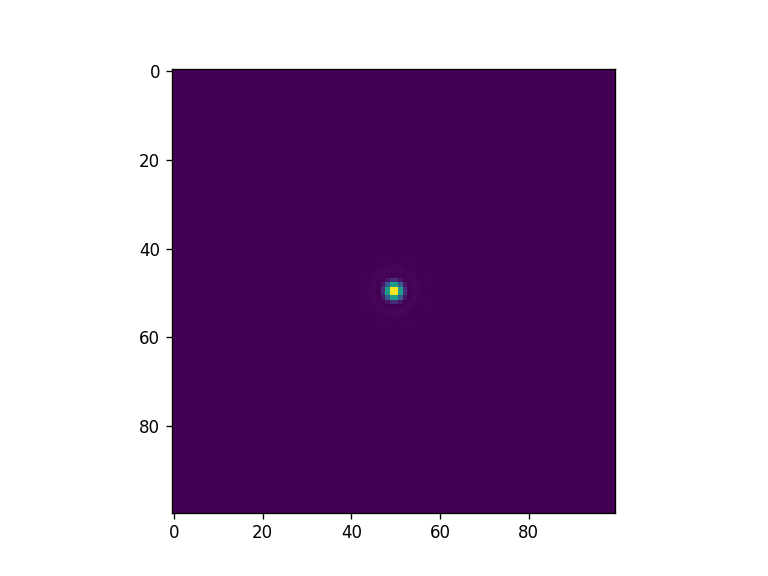

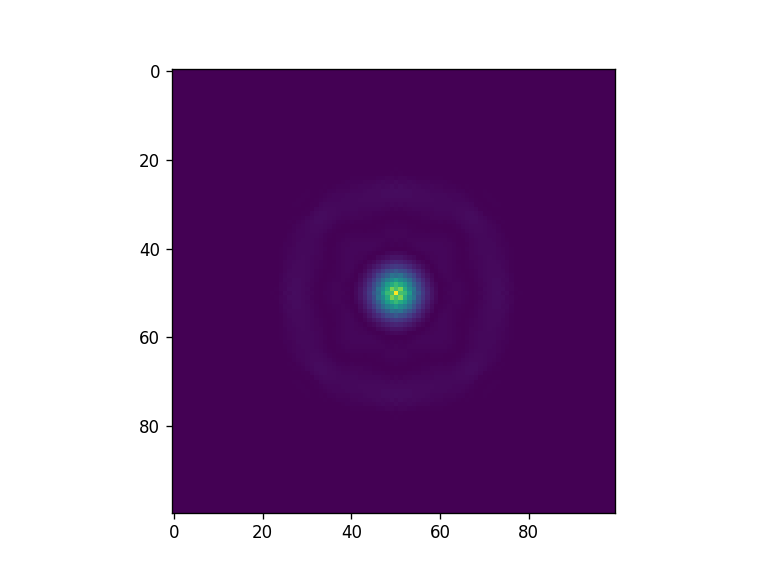

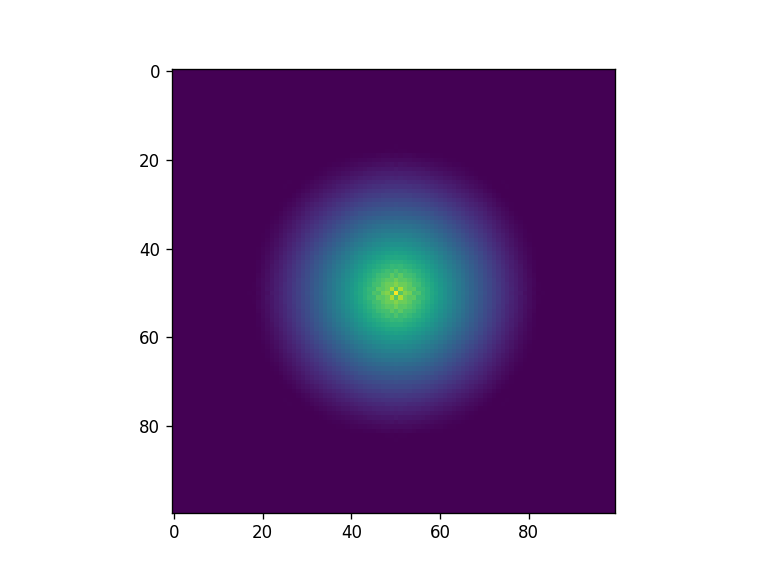

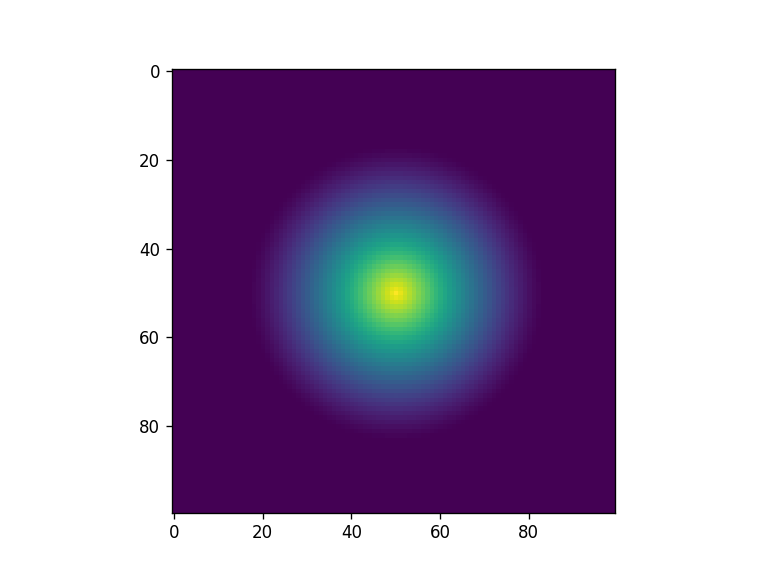

In [7]:
plt.figure() 

plt.imshow(np.abs(Exy.screen)**2) 

plt.figure()

plt.imshow(np.abs(o1) )

plt.figure()

plt.imshow(np.abs(o2) )

plt.figure()
plt.imshow(np.abs(OTF_ideal) )

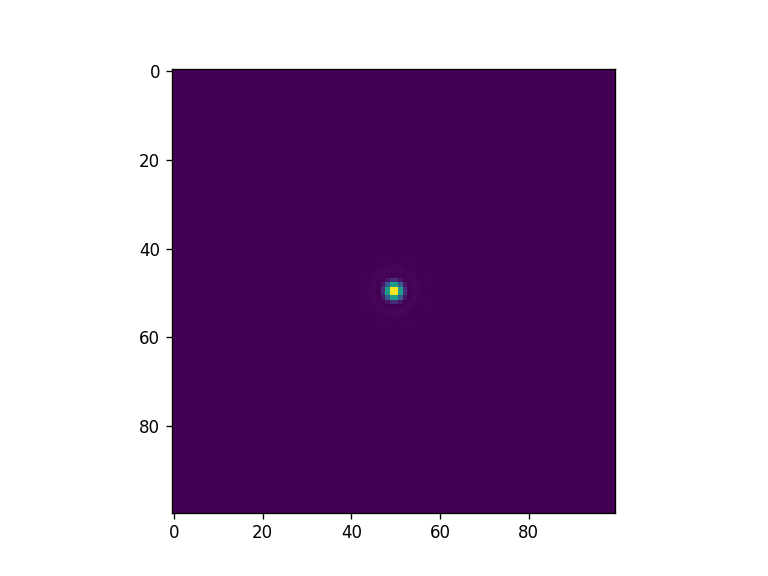

In [8]:
max([max(Exy.x), max(Exy.y)])
Exy.z[0]


fig = plt.figure() 
plt.imshow(np.abs(Exy.screen)**2)

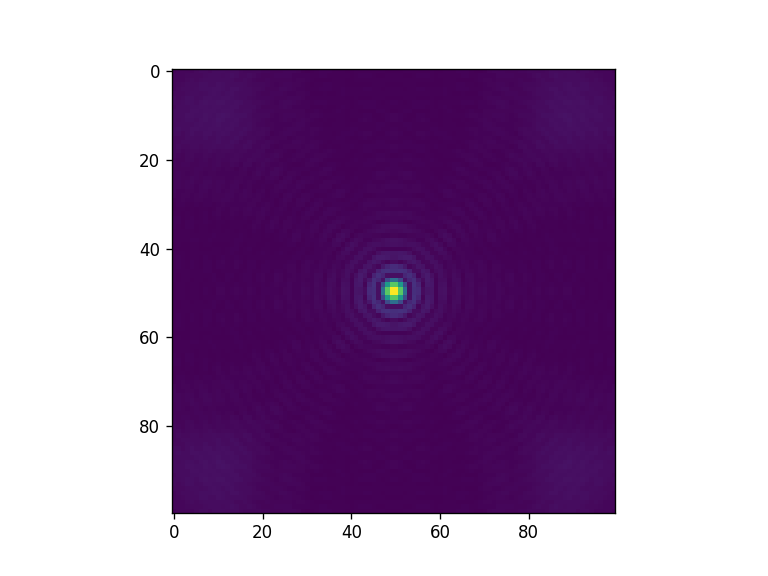

In [9]:
fig= plt.figure() 
plt.imshow(np.abs(Exy.screen) )

## Modulation Transfer Function (MTF) and Phase Transfer Function (PTF) & Strehl ratio 

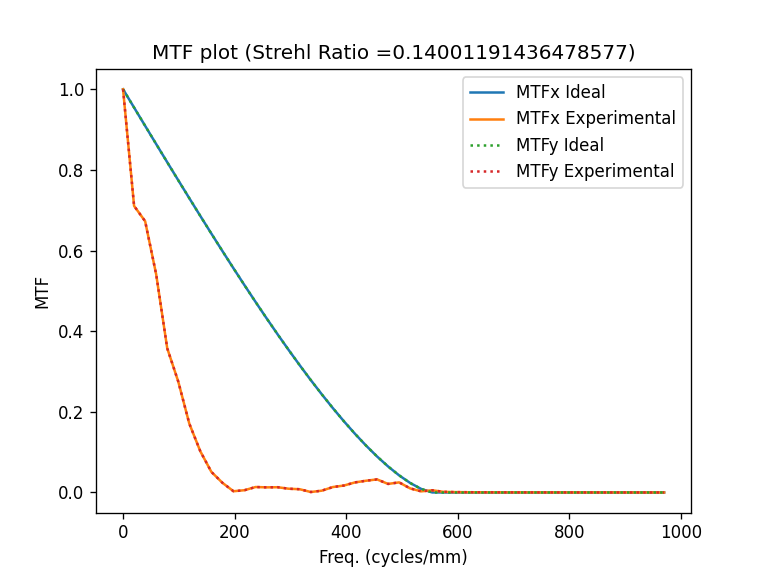

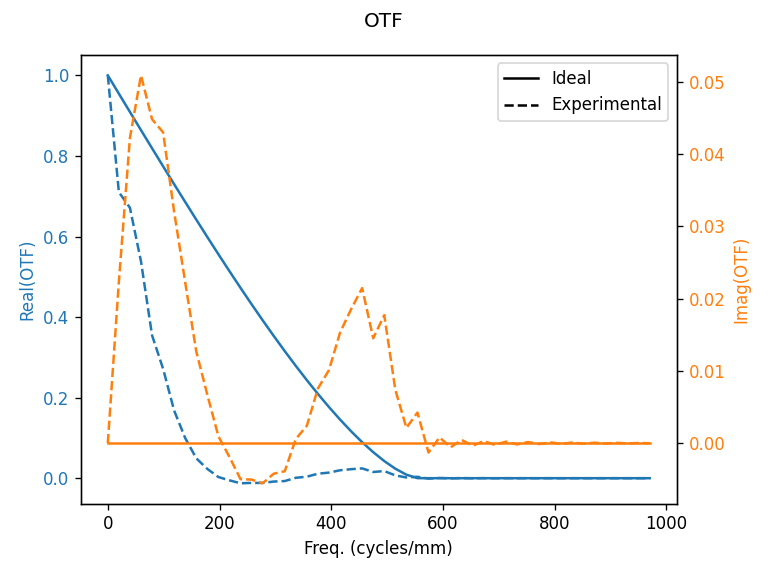

In [10]:
# MTF and OTF at DEFOCUSED PLANE 

strehlv1 = moe.metrics.strehl_ratio(np.abs(screen.screen[:,:,-1] )**2, screen, max([max(Exy.x), max(Exy.y)])*2, wavelength, screen.z[-1], strehl_from_mtf=True, plot_MTF=True, plot_OTF=True) 

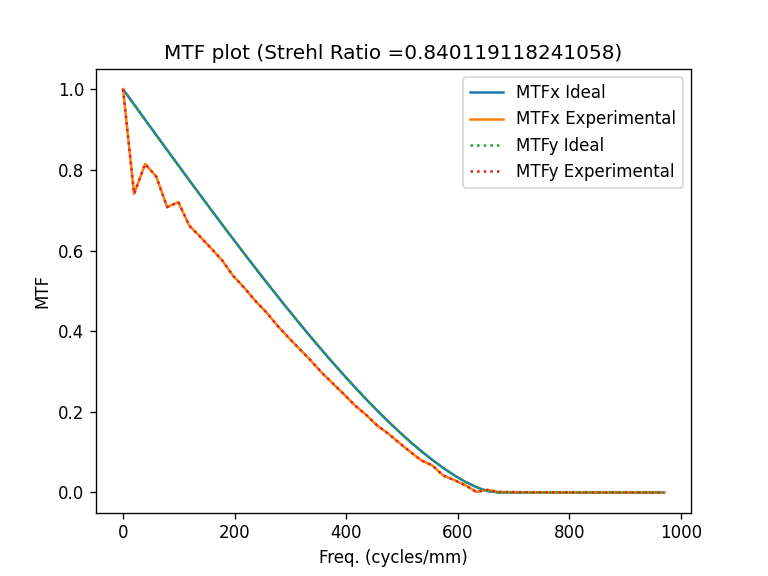

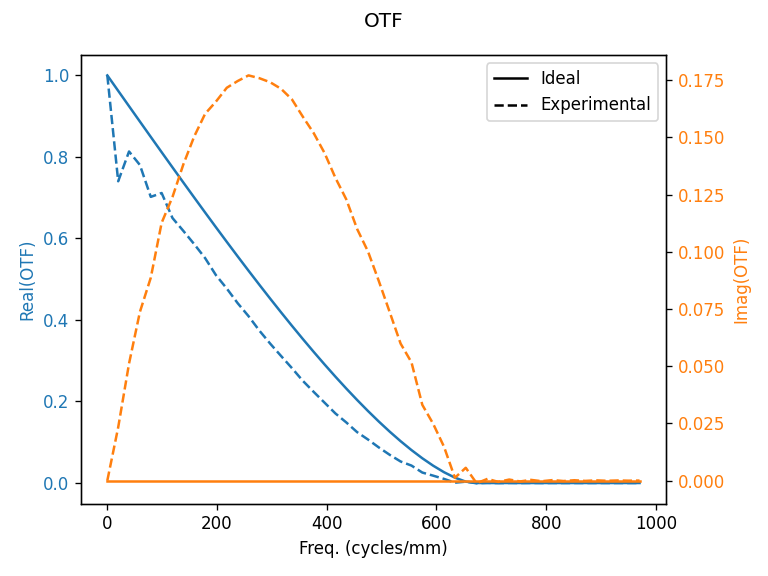

In [11]:
# MTF and OTF at FOCUSED PLANE

strehlv2 = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1] )**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, strehl_from_mtf=True, plot_MTF=True, plot_OTF=True )



In [12]:
strehlv1, strehlv2

(0.14001191436478577, 0.840119118241058)

(0.7306063927583829, 0.7306063927583829)

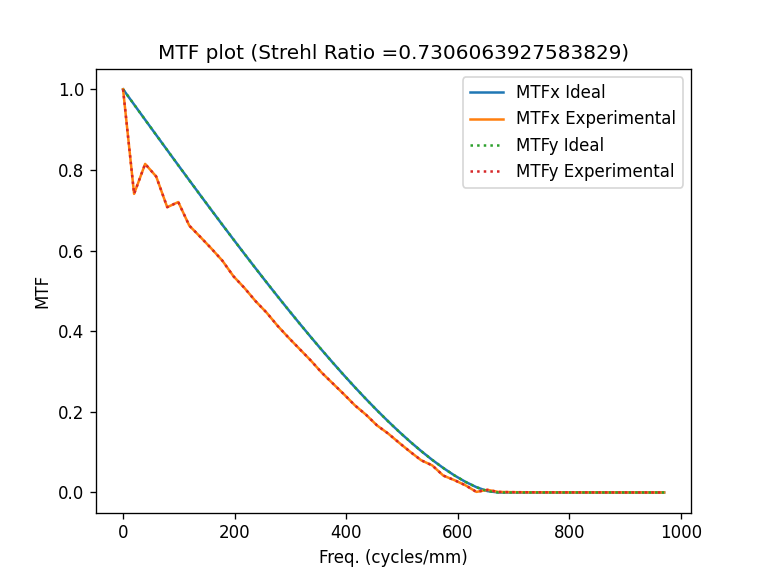

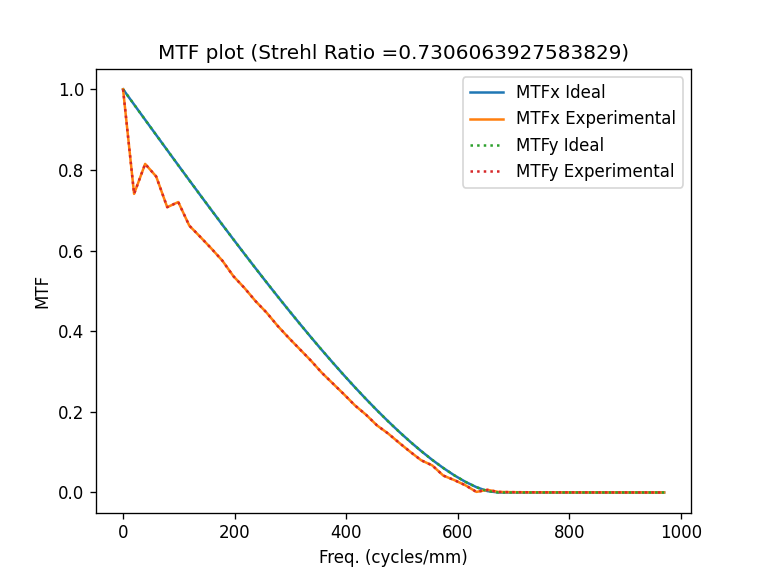

In [13]:
moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, screen, max([max(screen.x), max(screen.y)])*2, wavelength, focal_length, plot_MTF=True) ,\
moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

## Encircled energy 

Text(0.5, 1.0, 'Encircled energy')

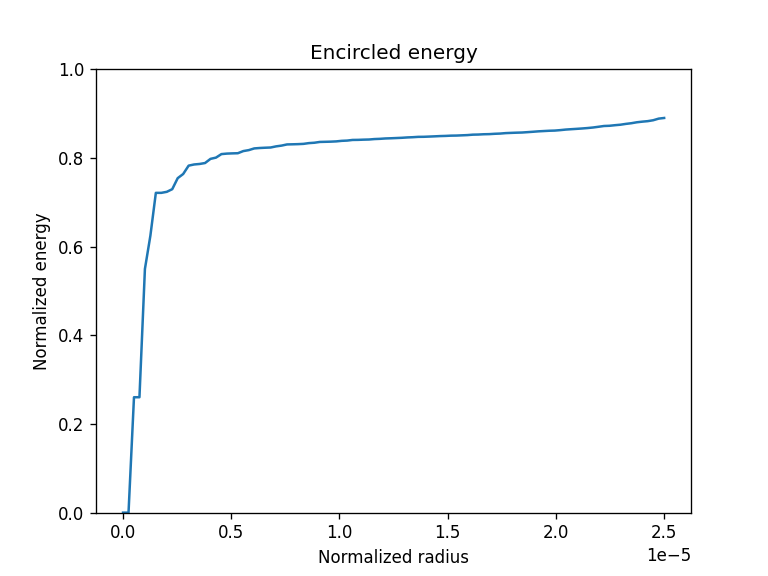

In [14]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray]
enmax = moe.metrics.encircled_energy(Exy, 1.01)

fig = plt.figure() 

plt.plot(parray, enarray/enmax)
plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Normalized energy")
plt.title("Encircled energy")
#plt.yscale("log")

#This is not exactly one, because other energy is lost to the square parts of the sensor 


#The energy plateus at 0.5e-6, so makes sense to use that as p 

In [15]:
XY=np.abs(Exy.screen[:,:,-1])**2


largestpeak_height , largestpeak_width, position = moe.metrics.find_FWHM_2d(XY, prominence=0.5)

largestpeak_height , largestpeak_width, position

(1.3879175930586803e+22, 5.499479222542831, array([50, 50], dtype=int64))

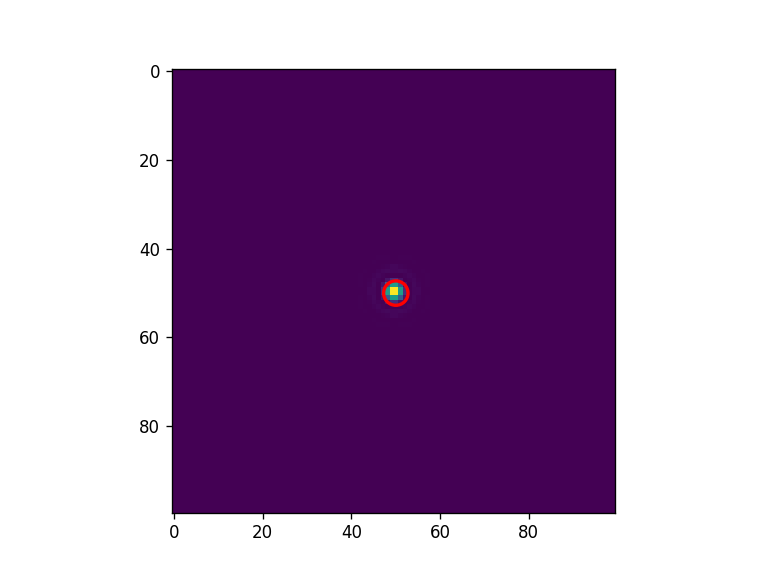

In [16]:
from matplotlib.patches import Circle 

fig = plt.figure() 

plt.imshow(np.abs(XY))

# Get image dimensions
height, width = XY.shape

# Add central circle
circle = Circle((position[0], position[1]), radius=largestpeak_width/2, color='red', fill=False, linewidth=2)
plt.gca().add_patch(circle)

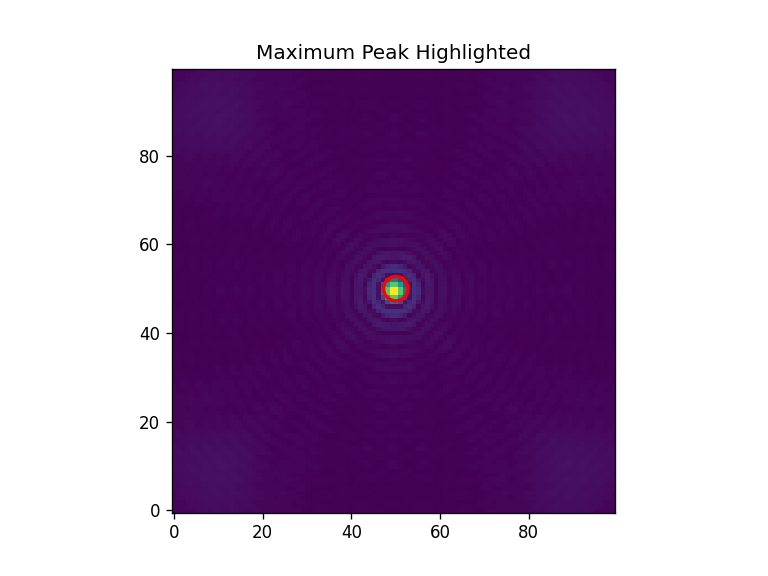

In [17]:
largestpeak_height , largestpeak_width, largestpeak_position = moe.metrics.find_FWHM_2d(np.abs(Exy.screen[:,:,-1])**2, prominence=0.5)


from matplotlib.patches import Circle

fig, ax = plt.subplots()
ax.imshow(np.abs(Exy.screen[:,:,-1]),  origin='lower')

# Draw the circle
circle = Circle((largestpeak_position[0], largestpeak_position[1]),  # x, y
                radius=largestpeak_width/2, color='red', fill=False, linewidth=2)
ax.add_patch(circle)

# Optional: mark the center
#ax.plot(largestpeak_position[0], largestpeak_position[1], 'ro')  # center dot

plt.title("Maximum Peak Highlighted")
plt.show()

In [18]:
##encircled energy at 1 FWHM 

one_fwhm = moe.metrics.encircled_energy(Exy, (width/2)*pixsize)/moe.metrics.encircled_energy(Exy, 1.01)

##encircled energy at 0.5 FWHM 

half_fwhm = moe.metrics.encircled_energy(Exy, (width/2)*pixsize*0.5)/moe.metrics.encircled_energy(Exy, 1.01)


(width/2)*pixsize, one_fwhm, half_fwhm 
#This is consistent with the plateauing that is seen in the encircled energy 

(4.9999999999999996e-05, 1.0, 0.8898340172814078)

## Ensquared energy 

Text(0.5, 1.0, 'Ensquared energy')

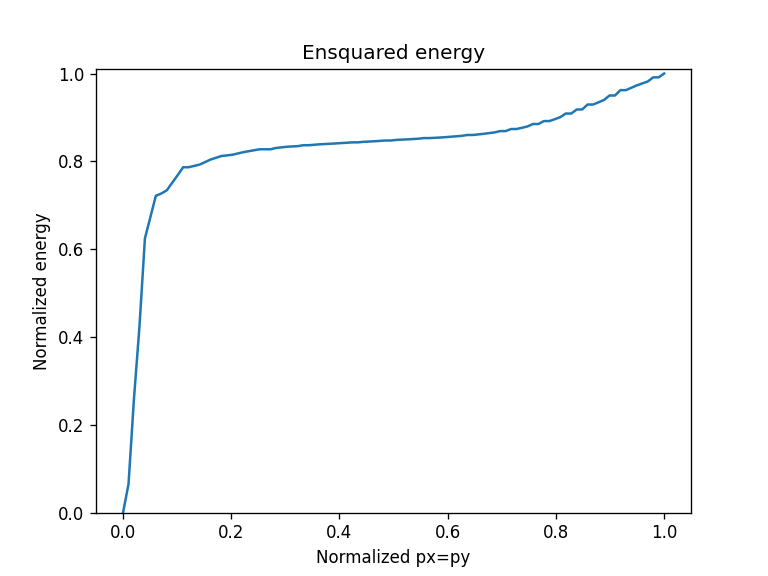

In [19]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

enarray = [moe.metrics.ensquared_energy(Exy, p, p) for p in parray]
enmax = moe.metrics.ensquared_energy(Exy, 1,1)

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), enarray/enmax)
plt.ylim([0,1.01])
plt.xlabel("Normalized px=py")
plt.ylabel("Normalized energy")
plt.title("Ensquared energy")

## Focusing Efficiency

Text(0.5, 1.0, 'Focusing Efficiency')

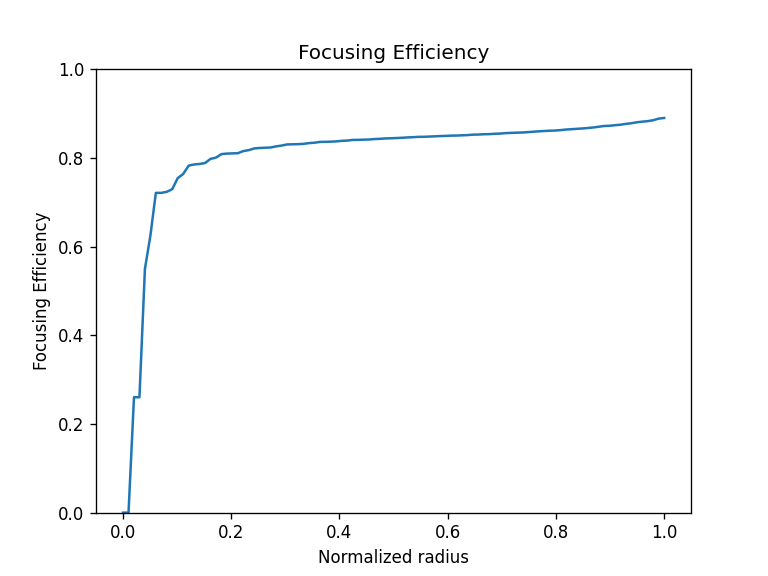

In [20]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

#Should give the same as the enclircled energy 
farray1 = [moe.metrics.focus_efficiency(Exy, p,  encircled_energy(Exy, 1.01),center=(0,0),) for p in parray]

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), farray1)
plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Focusing Efficiency")
plt.title("Focusing Efficiency")
#plt.yscale("log")

## Optical Performance Metric (OPM)

Text(0.5, 1.0, 'Engelberg OPM')

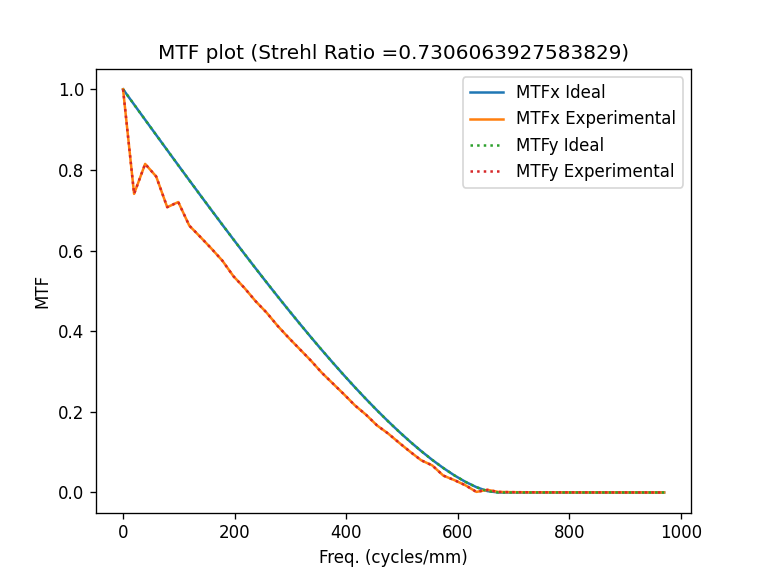

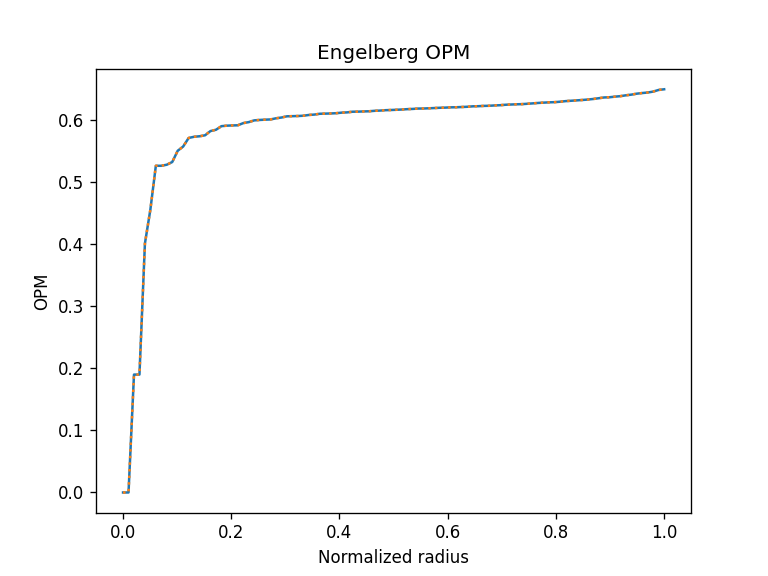

In [21]:
#Engelberg metric, check original paper for more detail 

center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

farray2 = [moe.metrics.Engelberg_OPM(Exy, p,  moe.metrics.encircled_energy(Exy, 1.01),1, wavelength, z = focal_length) for p in parray]
strehlr = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), farray2)
plt.plot(parray/(aperture_width/2), strehlr*np.array(farray1), ':' )
#plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("OPM")
plt.title("Engelberg OPM")

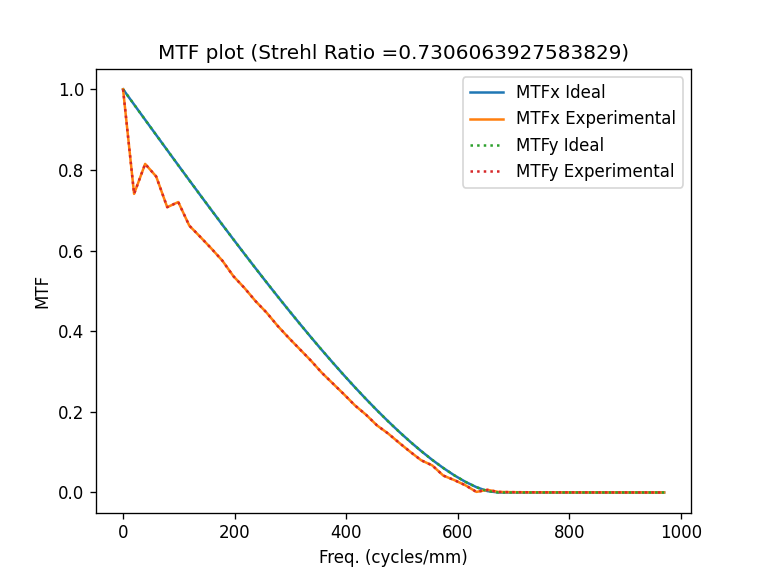

In [22]:
strehlr = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,0])**2, screen, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

## Comparisons to theoretical (analytical)

In [23]:
# Make circular apertures (returns also the 2D array)

wavelength = 1550e-9 #m

 
pixsize = 1e-6
x_pixel = 64
y_pixel = 64
 
aperture_width  = x_pixel*pixsize
aperture_height = y_pixel*pixsize

radius = 0.5*x_pixel*pixsize #m 
zdist = 10*radius #m

#screen size 
xminus = -400e-3 #m
xplus = 400e-3 #m 


# Define Aperture
aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture from phase mask 
mask = moe.generate.circular_aperture(aperture, radius=radius, center=(0,0))

# Define Phase mask 
mask_phase = moe.generate.create_empty_aperture_from_aperture(aperture)
mask_phase.aperture = mask.aperture*np.pi


# Plot the circular mask
#moe.plotting.plot_aperture(mask_phase)



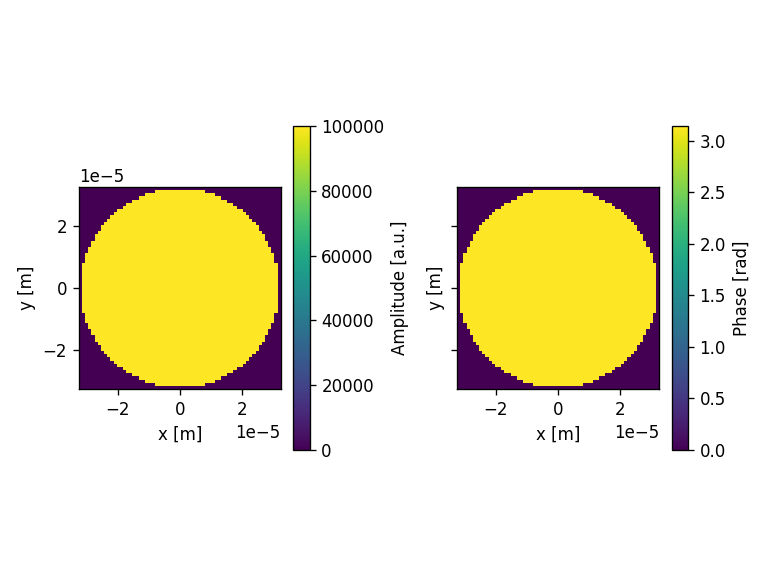

Progress: [####################] 100.0%
Elapsed: 0:00:01.064330


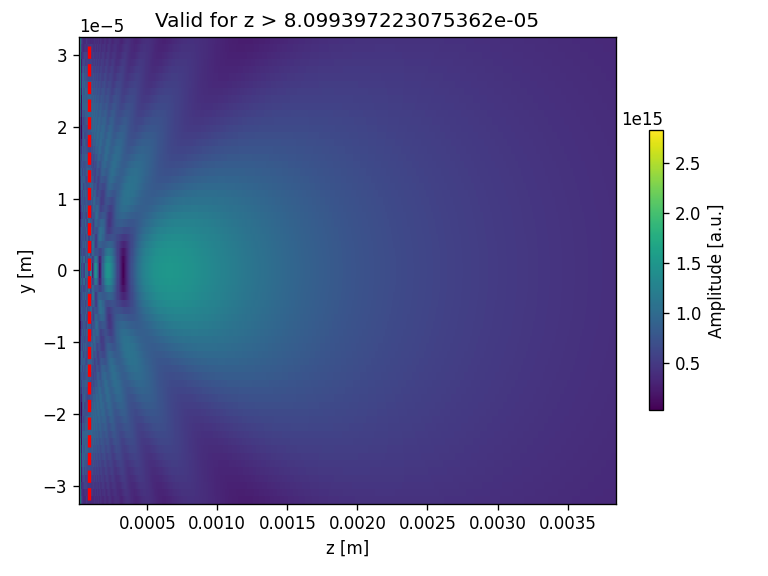

C:\ProgramData\anaconda3\Lib\site-packages\numpy\ma\core.py:3375: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


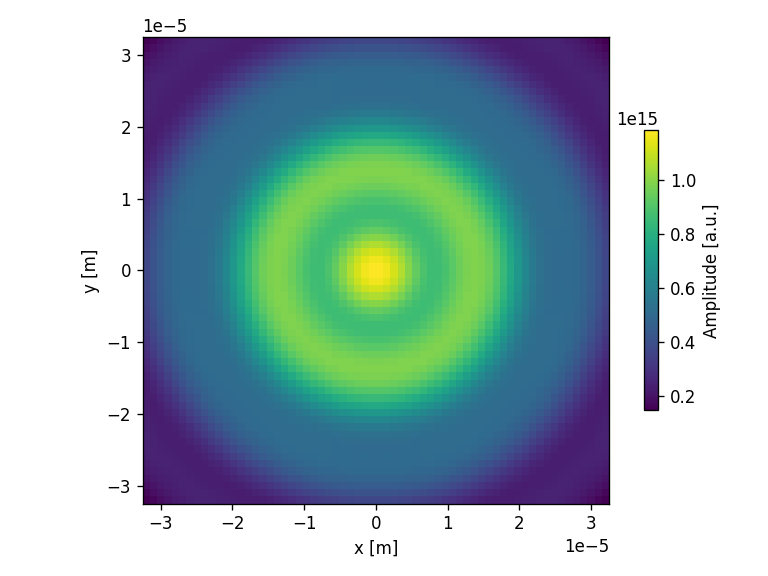

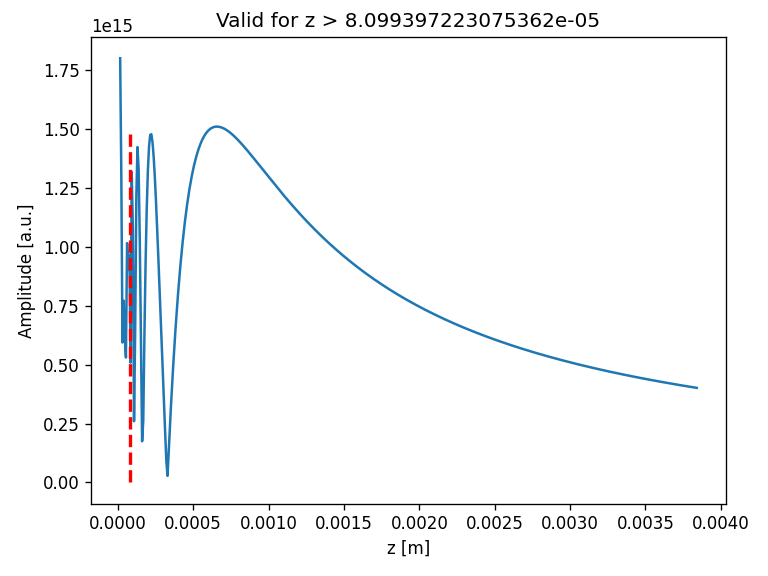

In [24]:
###Propagate field *10and calculate in plane YZ, using npix bins in Y
zdist=100*radius
zmin = wavelength*10
zmax = 1.2* zdist
nzs = 500

focal_length = 3.5e-4


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.linspace(zmin, zmax, nzs)

# Calculates a field to use with the calculated mask

# Initialize a Field from the Aperture mask 
field = moe.field.create_empty_field_from_aperture(mask)

# Generate a uniform field
field = moe.field.generate_uniform_field(field, E0=1e5)

# Or Gaussian field is also available 
#field = moe.field.generate_gaussian_field(field, E0=1, w0=100*micro)

# Modulates the field with a given aperture that can be used either as an amplitude mask or a phase mask
field = moe.field.modulate_field(field, amplitude_mask=mask, phase_mask=mask_phase)

###Propagate field *10and calculate in plane YZ, using npix bins in Y
zdist=100*radius
zmin = wavelength*10
zmax = 1.2* zdist
nzs = 500

focal_length = 4.5e-4


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.linspace(zmin, zmax, nzs)

# Calculates a field to use with the calculated mask

# Initialize a Field from the Aperture mask 
field = moe.field.create_empty_field_from_aperture(mask)

# Generate a uniform field
field = moe.field.generate_uniform_field(field, E0=1e5)

# Or Gaussian field is also available 
#field = moe.field.generate_gaussian_field(field, E0=1, w0=100*micro)

# Modulates the field with a given aperture that can be used either as an amplitude mask or a phase mask
field = moe.field.modulate_field(field, amplitude_mask=mask, phase_mask=mask_phase)

# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)

plt.tight_layout()
plt.show()


screen = moe.field.Screen(x,y,z)

# Propagate the field 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)

Eyz = moe.field.Screen(0,y,z)
Eyz.screen = np.reshape(EXYZ.screen[:,int(y_pixel/2), :], np.shape(Eyz.screen[:, :, :]))

moe.plotting.plot_screen_YZ(Eyz, which='amplitude')

limitx = moe.propagate.Fresnel_criterion(wavelength,radius)
plt.vlines(limitx, -radius, radius, colors='red', linestyles='dashed', lw=2)

plt.title("Valid for z > "+str(limitx))

plt.show()

Exy = moe.field.Screen(x,y,[focal_length])
Exy.screen = np.reshape(EXYZ.screen[:,:, int(focal_length/zmax*nzs)], np.shape(Exy.screen[:, :, :]))

moe.plotting.plot_screen_XY(Exy, which='amplitude')

Ezz = moe.field.Screen(0,0,z)
Ezz.screen = np.reshape(EXYZ.screen[int(x_pixel/2),int(y_pixel/2),:], np.shape(Ezz.screen[:, :, :]))

moe.plotting.plot_screen_ZZ(Ezz, which='amplitude')

limitx = moe.propagate.Fresnel_criterion(wavelength,radius)
plt.vlines(limitx, 0, np.max(Ezz.screen), colors='red', linestyles='dashed', lw=2)

plt.title("Valid for z > "+str(limitx))

plt.show()

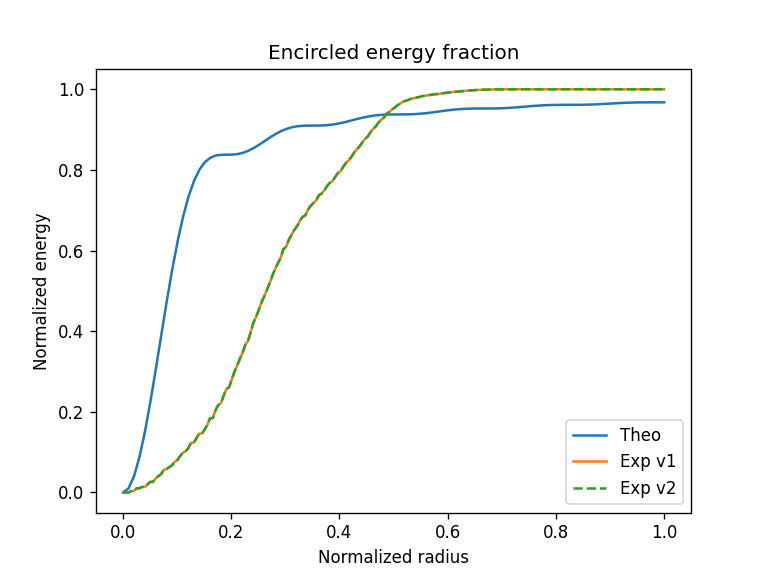

In [25]:
## RESULT TO BE CHECKED, MISMATCH MAYBE DUE TO DISTINCT DEFINITION OF RADIUS p ??

center=(0,0)

parray1 = np.linspace(0, aperture_width, 200)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax = moe.metrics.encircled_energy(Exy, 1.01)


parray2 = np.linspace(0, aperture_width*10, 100)
enarray_theo = [moe.metrics.theoretical_encircled_energy(Exy, p) for p in parray2]
enmaxtheo = moe.metrics.theoretical_encircled_energy(Exy, 1.01)


enarray2 = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax2 = moe.metrics.encircled_energy(Exy, 1.01)


fig = plt.figure() 

plt.plot(parray2/parray2.max(), enarray_theo/enmaxtheo, label="Theo")
plt.plot(parray1/parray1.max(), enarray/enmax, label = "Exp v1")

plt.plot(parray1/parray1.max(), enarray2/enmax2 , '--', label ="Exp v2")

plt.xlabel("Normalized radius")
plt.ylabel("Normalized energy")
plt.title("Encircled energy fraction")

plt.legend()

#This is not exactly one, because other energy is lost to the square parts of the sensor 

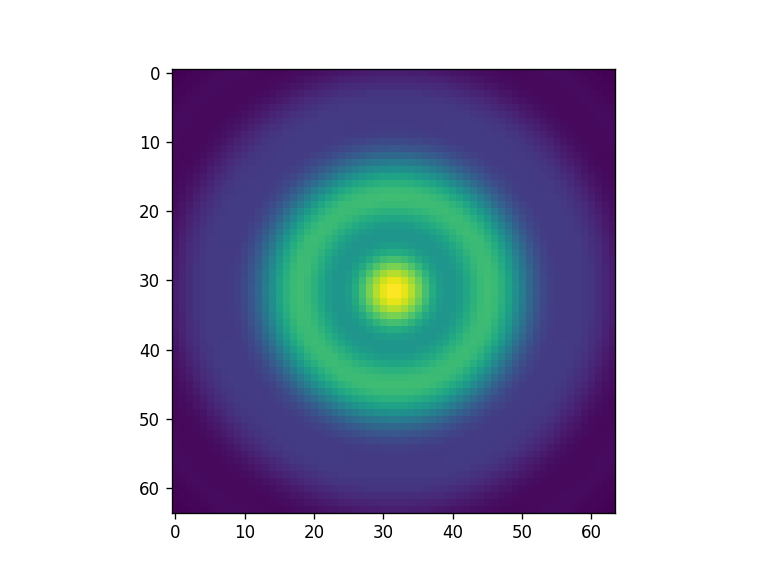

In [26]:
fig = plt.figure()
plt.imshow(np.abs(Exy.screen[:,:,-1])**2)

Picking up the last z propagated assumed to be the screen position


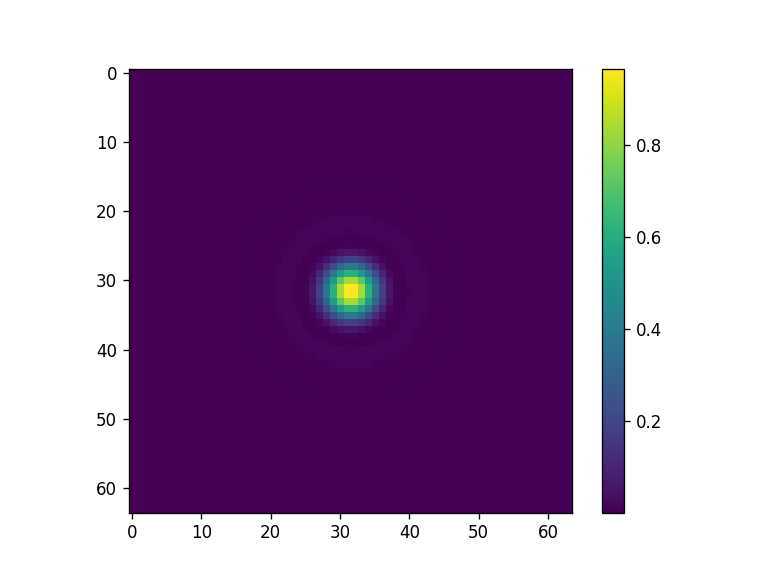

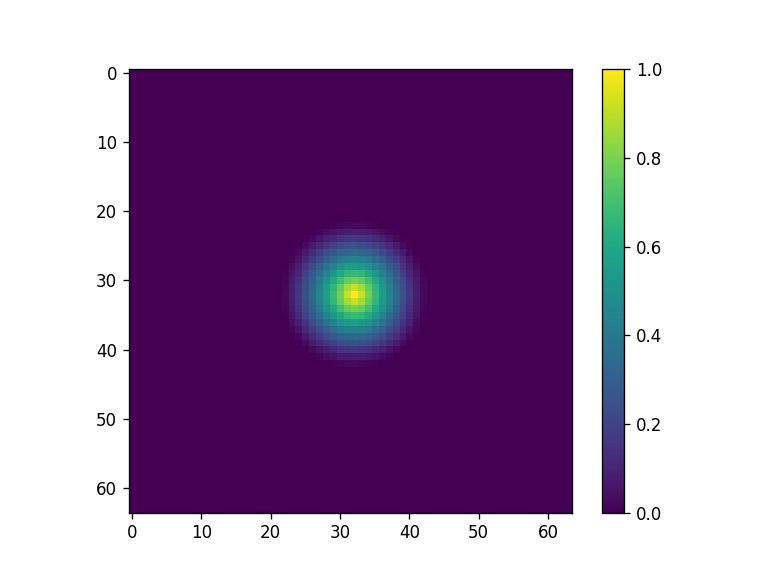

<Figure size 768x576 with 0 Axes>

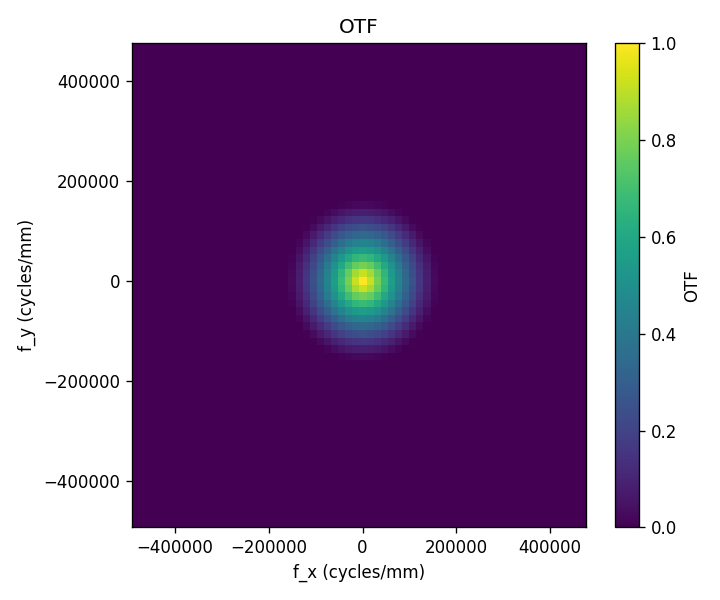

In [27]:
#Sanity check with theoretical Airy pattern MTF, 
# here the theoretical and calculated MTFs should give the same with unitary Strehl ratio

D = np.max(Exy.x)*2        

wavelength = 200e-9  # Wavelength in meters (e.g., 550 nm)

intensity_circular = intensity_theo_Airy(screen, D*2, wavelength, z=1)


fig = plt.figure() 
plt.imshow(intensity_circular  )
plt.colorbar()

OTF_circular = calculate_OTF(intensity_circular)


fig = plt.figure()
plt.imshow(np.abs(OTF_circular) )
plt.colorbar()

fig = plt.figure()

N = 512
dx = 10e-6  # pixel pitch in meters
dy = 10e-6


# Plot
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(OTF_circular), extent=(np.min(Exy.fx), np.max(Exy.fx), np.min(Exy.fy), np.max(Exy.fy)),
           origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='OTF')
plt.xlabel('f_x (cycles/mm)')
plt.ylabel('f_y (cycles/mm)')
plt.title('OTF')
plt.tight_layout()
plt.show()

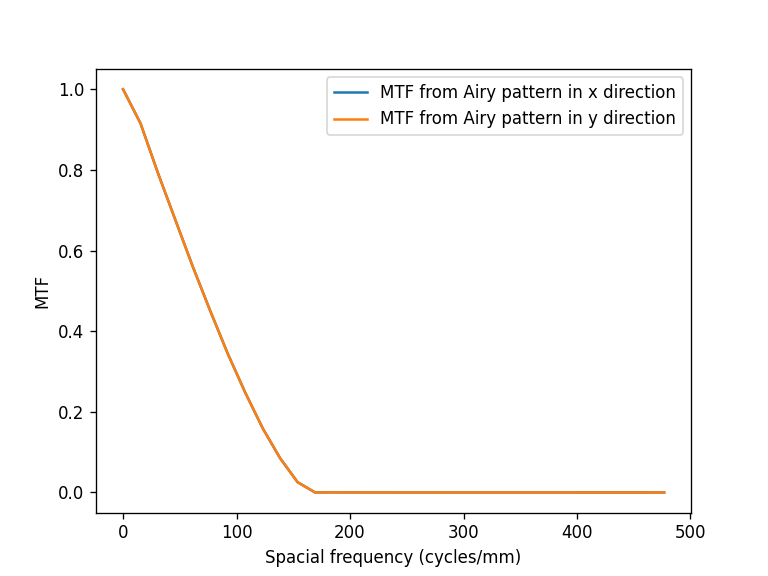

In [28]:
mtf, mtfx1, mtfy1 = moe.metrics.MTF_from_OTF(OTF_circular)


fx, fy = screen.fx*1e-3, screen.fy *1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

plt.legend()


In [29]:


otf = moe.metrics.theoretical_ideal_OTF(screen, D*2, wavelength, screen.z[-1]) 

mtf, mtfx2, mtfy2 = moe.metrics.MTF_from_OTF(otf)

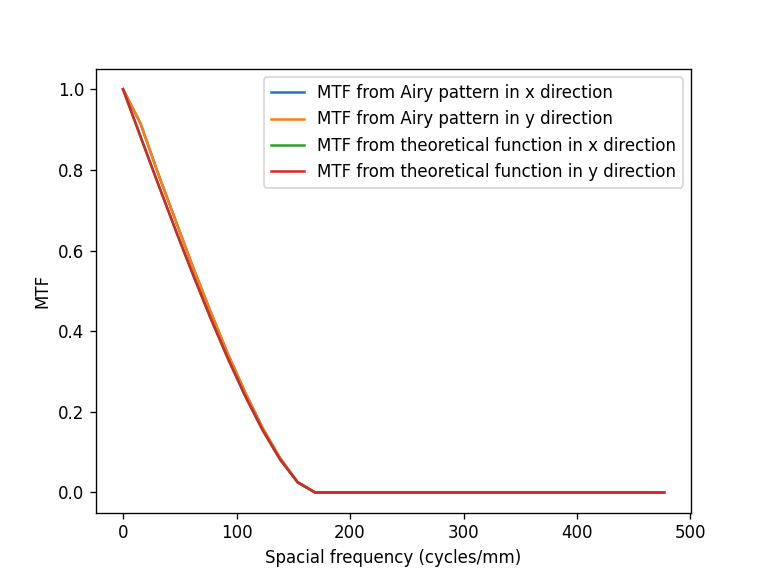

In [30]:
fx = screen.fx*1e-3
fy = screen.fy*1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.plot(fx[np.where(fx>=0)],  mtfx2, label="MTF from theoretical function in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy2, label="MTF from theoretical function in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

plt.legend()

In [31]:
#This should give 1 

moe.metrics.strehl_ratio(intensity_circular, screen, D*2, wavelength, z = screen.z[-1])

0.998955749058071